# Setup and imports

In [1]:
import os
import contextlib
import stan
import pandas as pd
import numpy as np
import scipy.stats as stats 
from datetime import datetime
import matplotlib.pyplot as plt
import pickle
import arviz as az
# this is a work around needed to run pystan in some machines
import nest_asyncio
nest_asyncio.apply()
from scipy.special import softmax
import pickle
import time
from concurrent.futures import ThreadPoolExecutor
from itertools import repeat

# Create a context manager to suppress all console output
@contextlib.contextmanager
def suppress_output():
    with open(os.devnull, "w") as fnull:
        with contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
            yield


# Functions

We create 2 datasets, one SD = Synthetic Data, corresponds to what would be the true data in an experiment. The other, SSD = Synthetic Simulated Data, corresponds to what would be the simulated data in an experiment.  To emulate what really happens in an experiment, SSD $!=$ SD, but it has many patterns of it.

The original observable space is 2D, $x_0$ and $x_1$.  Following CMS Arena idea (and usual HEP practices), we convert a grid in this 2D space into a histogram in a 1D space.

In [2]:
lda = """
functions {
// Parallel log-likelihood using aggregated counts per (document, bin),
// iterating only over nonzero bins for each document.
real partial_ll_counts(array[] int doc_slice, int start, int end,
array[] int pos,                 // length N+1, 1-based offsets
array[] int v_idx,               // length NNZ, bin indices
array[] int cnt,                 // length NNZ, counts
array[] vector log_theta,        // log(theta[d])
array[] vector log_W,            // log(W[k])
int K) {
real acc = 0;
int S = end - start + 1;

for (s in 1:S) {
  int d = doc_slice[s];            // document index
  int i1 = pos[d];
  int i2 = pos[d + 1] - 1;         // inclusive end
  if (i1 <= i2) {
    for (i in i1:i2) {
      int v = v_idx[i];
      int c = cnt[i];
      // log(sum_k theta[d,k] * W[k,v]) computed in log-space
      real lse = negative_infinity();
      for (k in 1:K)
        lse = log_sum_exp(lse, log_theta[d][k] + log_W[k][v]);
      if (c > 0) {acc += c * lse;}               // add all c observations at once
    }
  }
}
return acc;
}
}

data {
int<lower=1> N;                      // number of documents
int<lower=1> V;                      // number of bins (vocab size)
int<lower=1> K;                      // number of topics

// Sparse (ragged) representation of counts per document:
// Concatenate all nonzero (doc, bin) pairs across documents.
int<lower=0> NNZ;                    // total number of nonzero (doc, bin) entries
array[N + 1] int<lower=1, upper=NNZ + 1> pos;
// pos[d] is the 1-based starting index (into v_idx/cnt) for document d,
// and pos[d+1] is one past the end; require pos[1] == 1, pos[N+1] == NNZ + 1.

array[NNZ] int<lower=1, upper=V> v_idx; // bin index for each nonzero entry
array[NNZ] int<lower=0> cnt;            // count for each entry

vector<lower=0>[K] alpha;            // Dirichlet prior for theta rows
vector<lower=0>[V] eta;              // Dirichlet prior for W rows
int<lower=1> grainsize;              // e.g., 8–64 for per-doc slicing
}
transformed data {
// indices 1..N for reduce_sum slicing over documents
array[N] int doc_ids;
for (n in 1:N) doc_ids[n] = n;
}
parameters {
array[N] simplex[K] theta;           // doc-topic proportions
array[K] simplex[V] W;               // topic-word distributions
}
model {
// Priors
for (n in 1:N)
theta[n] ~ dirichlet(alpha);
for (k in 1:K)
W[k]   ~ dirichlet(eta);

// Precompute logs once per evaluation
array[N] vector[K] log_theta;
array[K] vector[V] log_W;
for (n in 1:N) log_theta[n] = log(theta[n]);
for (k in 1:K) log_W[k]     = log(W[k]);

// Parallelized likelihood over documents using counts (adds c * lse per bin)
target += reduce_sum(partial_ll_counts, doc_ids, grainsize, pos, v_idx, cnt, log_theta, log_W, K);
}"""

unmix = """
data {
int<lower=1> V;                           // number of bins
int<lower=1> K;                           // number of topics
int<lower=1> N;                           // number of observations
array[N] int<lower=1, upper=V> w;         // observed bin indices (1..V)

// Pre-fitted topic-word matrices for signal and background.
// Each row k is a simplex over V bins: W_c[k, v] = P(bin=v | topic=k, component=c)
array[K] simplex[V] W_signal;
array[K] simplex[V] W_background;

// Priors
vector<lower=0>[K] alpha_signal;          // Dirichlet prior for theta_s
vector<lower=0>[K] alpha_background;      // Dirichlet prior for theta_b
real<lower=0> a_pi;                       // Beta prior parameters for pi
real<lower=0> b_pi;
}

parameters {
simplex[K] theta_signal;                  // topic mixture for the signal component
simplex[K] theta_background;              // topic mixture for the background component
real<lower=0, upper=1> pi;                // fraction of signal in the data
}

transformed parameters {
// Implied per-bin distributions for each component (mixture over topics)
// phi_signal[v] = sum_k theta_signal[k] * W_signal[k, v]
// phi_background[v] = sum_k theta_background[k] * W_background[k, v]
vector<lower=0>[V] phi_signal;
vector<lower=0>[V] phi_background;

for (v in 1:V) {
real acc_s = 0;
real acc_b = 0;
for (k in 1:K) {
acc_s += theta_signal[k] * W_signal[k, v];
acc_b += theta_background[k] * W_background[k, v];
}
phi_signal[v] = acc_s;
phi_background[v] = acc_b;
}
}

model {
// Priors
theta_signal ~ dirichlet(alpha_signal);
theta_background ~ dirichlet(alpha_background);
pi ~ beta(a_pi, b_pi);

// Likelihood: for each observation w[n],
// P(w[n]) = pi * phi_signal[w[n]] + (1 - pi) * phi_background[w[n]]
// Use log_mix for numerical stability
for (n in 1:N) {
target += log_mix(pi, log(phi_signal[w[n]]), log(phi_background[w[n]]));
}
}

"""

# functions
def p_at_true(a,pi_true):
    """If 'a' is the histogram, then returns the valur of the histogram at the bin that contains p_true"""
    count = 0
    for i in a[1]:
        if i > pi_true: break
        count += 1
    #return a[0][count-1]/(a[1][1]-a[1][0])
    return a[0][count-1]


def smear_covariance_matrix(A, smearing=0.2, exception=[]):
    """Smear a covariance matrix normally around its values with std=smearing.
    If exception!=0, then the element exception[0],exception[1] is not smeared, but instead is fixed to exception[2] x its original value + exception[3]."""
    A = np.array(A)
    n = len(A)
    M = np.zeros((n, n), dtype=float) 
    while (np.linalg.det(M)<0 or sum(sum(M==0))==4): #keep on smearing until M is semi-definite positive to be a covariance
        for i in range(n):
            for j in range(i,n):
                if len(exception)>0 and i==exception[0] and j==exception[1]:
                    M[i,j] = A[i,j]*exception[2] + exception[3]
                    M[j,i] = M[i,j]
                else:
                    if i==j:
                        M[i,i] = abs(np.random.normal(A[i,i],max(smearing, A[i,i]*smearing)))
                    else:
                        M[i,j] = np.round(np.random.normal(A[i,j],max(smearing, A[i,j]*smearing)),2)
                        M[j,i] = M[i,j]
    return M

def smear_mean(mu, smearing=0.2, exception=[]):
    mu = np.array(mu)
    n = len(mu)
    Mu = np.empty(n, dtype=float)
    for i in range(n):
        if len(exception)>0 and i==exception[0]:
            Mu[i] = mu[i]*exception[1] + exception[2]
        else:            
            Mu[i] = np.round(np.random.normal(mu[i],max(smearing, mu[i]*smearing)),2) 
    return Mu
        

def generate_sd(mean_sd_signal, covariance_sd_signal, mean_sd_background, covariance_sd_background, Ns, Nb, rseed=0, mybinning=[[],[]]):
    # increase = 5 # factor to increase data such that the data in the fiducial region ends up being what was requested
    # np.random.seed(rseed)
    # sd_signal = pd.DataFrame(
    #     np.random.multivariate_normal(mean_sd_signal, covariance_sd_signal,int(increase*Ns)),
    #     columns = ['x'+str(s) for s in range(len(mean_sd_signal))])
    # sd_background = pd.DataFrame(
    #     np.random.multivariate_normal(mean_sd_background, covariance_sd_background,int(increase*Nb)),
    #     columns = ['x'+str(s) for s in range(len(mean_sd_background))])
    # mask_signal = (sd_signal['x0'] > min(mybinning[0])) & (sd_signal['x0'] < max(mybinning[0])) & (sd_signal['x1'] > min(mybinning[1])) & (sd_signal['x1'] < max(mybinning[1]))
    # mask_background = (sd_background['x0'] > min(mybinning[0])) & (sd_background['x0'] < max(mybinning[0])) & (sd_background['x1'] > min(mybinning[1])) & (sd_background['x1'] < max(mybinning[1]))
    # sd_signal = sd_signal.loc[mask_signal].head(Ns).reset_index(drop=True).copy()
    # sd_background = sd_background.loc[mask_background].head(Nb).reset_index(drop=True).copy()
    
    # if len(sd_background) < Nb: print('Atention, background length is: '+str(len(sd_background)) )
    # if len(sd_signal) < Ns: print('Atention, signal length is: '+str(len(sd_signal)) )
    
    np.random.seed(rseed)
    sd_signal = pd.DataFrame(
        np.random.multivariate_normal(mean_sd_signal, covariance_sd_signal,Ns),
        columns = ['x'+str(s) for s in range(len(mean_sd_signal))])
    sd_background = pd.DataFrame(
        np.random.multivariate_normal(mean_sd_background, covariance_sd_background,Nb),
        columns = ['x'+str(s) for s in range(len(mean_sd_background))])

    plt.scatter(sd_background['x0'],sd_background['x1'], s=0.5)
    plt.scatter(sd_signal['x0'],sd_signal['x1'], s=0.8)  # plot signal on top of background and slightly larger for better visualization
    for vline in mybinning[0]:
        plt.axvline(x=vline, linewidth=0.5, linestyle='dashed', color='black')
    for hline in mybinning[1]:
        plt.axhline(y=hline, linewidth=0.5, linestyle='dashed', color='black')
    plt.show()
    
    #### Data as a whole
    sd_data = pd.concat([sd_signal, sd_background])
    # Shuffle the merged DataFrame in place
    sd_data = sd_data.sample(frac=1).reset_index(drop=True)
    
    sd_data_hist  = flat_histogramdd(sd_data, mybinning)
    
    # For the sake of the inference problem, we better have the data as events, where each event is the bin number
    bins = [x-0.5 for x in range(len(sd_data_hist))]  # Bin edges
    frequencies = sd_data_hist  # Frequencies in each bin
    
    sd_data_hist1 = []
    for bin_edge, freq in zip(bins, frequencies):
        sd_data_hist1.extend([bin_edge+0.5] * int(freq))
        
    
    X0 = sd_data_hist
    # This is our data!!!! (we start with bin=1 because of STAN that starts counting on 1 and not on 0)
    X = [int(x+1) for x in sd_data_hist1]
    np.random.shuffle(X)
    return X, sd_signal, sd_background


def flat_histogramdd(df, bins):
    """Receives a dataframe of D dimensions and N datapoints; and a list of how to bin in each one of the D dimensions.
    Returns a flatten historgram with the counting of datapoints in each bin in the D-dimensional grid."""
    cols = df.columns[:len(bins)]
    edges = [np.asarray(b) for b in bins]
    data = df[cols].dropna().to_numpy()
    return np.histogramdd(data, bins=edges)[0].ravel()

def normalize(a, epsilon=0.001):
    a = a + epsilon
    a = list(a)
    a = [x/sum(a) for x in a]
    #b = np.round(a / np.sum(a),4)
    #print(np.sum(b))
    return a

def normalize_prob(x,epsilon=0.0001):
    x = x + epsilon
    x = np.asarray(x, dtype=np.float64)
    s = x.sum(dtype=np.float64)
    y = x / s
    i = y.argmax()                     # adjust the largest to keep all positive
    y[i] += 1.0 - y.sum(dtype=np.float64)
    return y

## Following function is without requesting exact Ns, Nb
# def generate_ssd(mean_sd, covariance_sd, mybinning, exclusion, var, bias, num_ssd, ssd_length):
#     count = 0
#     means = []
#     covs = []
#     DF_ssd = []
#     Y = []
#     [true_mean_x0, true_mean_x1] = [mean_sd[0], mean_sd[1]] # removed the '+ bias' from here
#     [[true_sigma, true_covariance], [_, _]] = covariance_sd
#     while (count < num_ssd):
#         biased_mean_x0 = np.random.normal(true_mean_x0, var)
#         biased_mean_x1 = np.random.normal(true_mean_x1+bias, var) # and put it here
#         biased_sigma = abs(np.random.normal(true_sigma, var))
#         biased_covariance = np.random.normal(true_covariance, var)
#         if (((biased_mean_x0 - true_mean_x0)**2 + (biased_mean_x1 - true_mean_x1)**2 > exclusion**2) and # so that here we correctly exclude what we want
#             abs(biased_sigma - true_sigma) > exclusion and
#             abs(biased_covariance - true_covariance) > exclusion/2 and
#             (biased_sigma > 0) and
#             (biased_sigma**2 - biased_covariance**2 > 0)):
#             count += 1
#             mean_ssd = [biased_mean_x0, biased_mean_x1]
#             covariance_ssd = [[biased_sigma, biased_covariance],
#                                          [biased_covariance, biased_sigma]]
#             means.append(mean_ssd)
#             covs.append(covariance_ssd)
#             t1 = pd.DataFrame(np.random.multivariate_normal(mean_ssd, covariance_ssd, ssd_length), 
#                 columns=['x'+str(s) for s in range(len(mean_sd))])
#             DF_ssd.append(t1)
#             t2 = normalize_prob(flat_histogramdd(t1,mybinning))
#             Y.append(list(t2))
        
#     return DF_ssd, np.array(Y)
def generate_ssd(mean_sd, covariance_sd, mybinning, exclusion, var, bias, num_ssd, ssd_length):
    increase = 5
    count = 0
    means = []
    covs = []
    DF_ssd = []
    Y = []
    [true_mean_x0, true_mean_x1] = [mean_sd[0], mean_sd[1]] # removed the '+ bias' from here
    [[true_sigma, true_covariance], [_, _]] = covariance_sd
    while (count < num_ssd):
        biased_mean_x0 = np.random.normal(true_mean_x0, var)
        biased_mean_x1 = np.random.normal(true_mean_x1+bias, var) # and put it here
        biased_sigma = abs(np.random.normal(true_sigma, var))
        biased_covariance = np.random.normal(true_covariance, var)
        if (((biased_mean_x0 - true_mean_x0)**2 + (biased_mean_x1 - true_mean_x1)**2 > exclusion**2) and # so that here we correctly exclude what we want
            abs(biased_sigma - true_sigma) > exclusion and
            abs(biased_covariance - true_covariance) > exclusion/2 and
            (biased_sigma > 0) and
            (biased_sigma**2 - biased_covariance**2 > 0)):
            if count % 100 ==0: print('Count=', count)
            count += 1
            mean_ssd = [biased_mean_x0, biased_mean_x1]
            covariance_ssd = [[biased_sigma, biased_covariance],
                                         [biased_covariance, biased_sigma]]
            means.append(mean_ssd)
            covs.append(covariance_ssd)
            # Generate more than required, then adjust the required in fiduciary region
            t1 = pd.DataFrame(np.random.multivariate_normal(mean_ssd, covariance_ssd, int(increase*ssd_length)), 
                columns=['x'+str(s) for s in range(len(mean_sd))])
            t1 = t1[(t1['x0'] >= min(mybinning[0])) & (t1['x0'] < max(mybinning[0])) & (t1['x1'] >= min(mybinning[1])) & (t1['x1'] < max(mybinning[1]))]
            t1 = t1.head(ssd_length).reset_index(drop=True).copy()
            if (len(t1)) != ssd_length: print('Error in length: SSD #',count,'has',len(t1),'events and it should have', ssd_length)
            
            DF_ssd.append(t1)
            t2 = normalize_prob(flat_histogramdd(t1,mybinning))
            Y.append(list(t2))
        
    return DF_ssd, np.array(Y)
    
def convert(list_of_dataframes, mybinning):
    #convert all SSD signal events into 3 lists to feed the LDA model
    cnt = []
    v_idx = []
    pos = [1]
    for i in range(len(list_of_dataframes)):
        counts = flat_histogramdd(list_of_dataframes[i], mybinning)
        int_counts = counts.astype(int)
        for i in range(len(int_counts)):
            v_idx.append(i+1)
            cnt.append(int_counts[i])
        pos.append(pos[-1]+len(int_counts))
    return cnt, v_idx, pos

def lda_function(thedata, nsamples, nwarmup, mydelta, rseed=0):
    model = stan.build(lda, data=thedata, random_seed=rseed)
    fit = model.sample(num_chains=4, num_samples=nsamples, num_warmup=nwarmup, delta=mydelta)  # threads per chain)
    samples = fit.to_frame() 
    samples.sort_values(by='lp__', inplace=True, ascending=False)
    #
    # Let's diagnose the inference, we plot Rhat to assess chains convergence
    azdata = az.from_pystan(fit)
    summary = az.summary(azdata)
    tmp = summary['r_hat']
    print('Rhat (max, mean, std):', np.max(tmp), np.mean(tmp), np.std(tmp))
    plt.hist(tmp, density=1, bins=np.linspace(1,3,30))
    plt.show()
    #
    return samples, summary

def unmix_data(data_unmix, num_samples, num_warmup, delta, random_seed=0, plot_it=1):
    model_unmix = stan.build(unmix, data=data_unmix, random_seed=random_seed)
    fit_unmix = model_unmix.sample(num_chains=4, num_samples=nsamples, num_warmup=nwarmup, delta=mydelta, refresh=0);
    samples_unmix = fit_unmix.to_frame() 
    samples_unmix.sort_values(by='lp__', inplace=True, ascending=False)
    #
    if plot_it==1:
        # Let's diagnose the inference, we plot Rhat to assess chains convergence
        azdata = az.from_pystan(fit_unmix)
        summary = az.summary(azdata)
        tmp = summary['r_hat']
        print('Rhat (max, mean, std):', np.max(tmp), np.mean(tmp), np.std(tmp))
        plt.hist(tmp, density=1, bins=np.linspace(1,3,30))
        plt.show()
        return samples_unmix, summary
    else:
        return samples_unmix

def unmix_bayesian(X, samples_s, samples_b,  V, K2, num_samples, num_warmup, delta, M=5, rseed=0):
    Ws_background = []
    #for m in range(M):
    for _ in range(M):
        m = np.random.randint(len(samples_b))
        W_background = []
        for k in range(1,K+1):
            topic = []
            for v in range(1,V+1):
                topic.append(samples_b.iloc[m]['W.'+str(k)+'.'+str(v)])
            W_background.append(topic)            
        Ws_background.append(W_background)
    
    Ws_signal = []
    #for m in range(M): # use this line for the most likely, use 2 lines below for random
    for _ in range(M):
        m = np.random.randint(len(samples_s))
        W_signal = []
        for k in range(1,K+1):
            topic = []
            for v in range(1,V+1):
                topic.append(samples_s.iloc[0]['W.'+str(k)+'.'+str(v)])
            W_signal.append(topic) 
        Ws_signal.append(W_signal)
    
    ################
    pis_bayesian = []
    for m in range(M):
        data_unmix =  { 
                    'V': (len(mybinning[0])-1) * (len(mybinning[1])-1),
                    'K': K2,
                    'N': len(X),
                    'w': np.array(X),
                    'W_signal': np.array(Ws_signal[m]),
                    'W_background': np.array(Ws_background[m]),
                    'alpha_signal': np.array([1]*K2),
                    'alpha_background': np.array([1]*K2),
                    'a_pi': 1,
                    'b_pi': 1}                
        samples_unmix, summary = unmix_data(data_unmix, num_samples=nsamples, num_warmup=nwarmup, delta=mydelta, random_seed=0);
        #model_unmix = stan.build(unmix, data=data_unmix, random_seed=rseed);
        #fit_unmix, summary = model_unmix.sample(num_chains=4, num_samples=nsamples, num_warmup=nwarmup, delta=mydelta);  # threads per chain)
        #samples_unmix = fit_unmix.to_frame() 
        pis_bayesian.extend(list(samples_unmix['pi'].values))
    return pis_bayesian
    
def unmix_data_for_parallel(one_argument):
    print('Launching a parallel run...')
    samples_unmix = unmix_data(one_argument[0], num_samples=one_argument[1], num_warmup=one_argument[2], delta=one_argument[3], random_seed=np.random.randint(10000), plot_it=0);
    return list(samples_unmix['pi'].values)

def run_unmix_M_times_concat(X, n_runs, workers):
    with ThreadPoolExecutor(max_workers=workers) as ex:
        # runs unmix_bayesian(X) 20 times in parallel (up to 10 at a time)
        results = list(ex.map(unmix_data_for_parallel, repeat(X, n_runs)))
    # flatten list-of-lists
    combined = [item for sub in results for item in sub]
    return combined



def assessment(p_signal, p_background, Ys, Yb, samples_unmix, runname=''):
    D = len(p_signal)
    samples_unmix.sort_values(by='lp__', ascending=False, inplace=True) # Therefore the first of the list corresponds to the MAP
    HL_S_posterior = []
    HL_B_posterior = []
    HL_S_prior = []
    HL_B_prior = []
    for i in range(len(samples_unmix)):
        # Get the binned signal posterior of the i-th sample
        tmp_S = []
        tmp_B = []
        for d in range(D):
            tmp_S.append(samples_unmix.iloc[i]['phi_signal.'+str(d+1)]) 
            tmp_B.append(samples_unmix.iloc[i]['phi_background.'+str(d+1)]) 
        # Compute the KL distance between the i-th sample and the true
        HL_S = 0
        HL_B = 0
        for n in range(len(p_signal)):
            HL_S += (np.sqrt(p_signal[n]) - np.sqrt(tmp_S[n]))**2
            HL_B += (np.sqrt(p_background[n]) - np.sqrt(tmp_B[n]))**2
        HL_S_posterior.append(np.sqrt(HL_S))
        HL_B_posterior.append(np.sqrt(HL_B))
    # Prior
    for i in range(len(Ys)):
        # First Signal
        # Get the binned signal posterior of the i-th prior sample
        tmp_S = Ys[i]
        tmp_B = Yb[i]
        # Compute the KL distance between the i-th sample and the true
        HL_S = 0    
        HL_B = 0
        for n in range(len(p_signal)):
            HL_S += (np.sqrt(p_signal[n]) - np.sqrt(tmp_S[n]))**2
            HL_B += (np.sqrt(p_background[n]) - np.sqrt(tmp_B[n]))**2
        HL_S_prior.append(np.sqrt(HL_S))    
        HL_B_prior.append(np.sqrt(HL_B))    
    #Plots
    mybins = np.linspace(0,max(max(HL_S_prior, HL_B_prior, HL_S_posterior, HL_B_posterior)),100)
    plt.hist(HL_S_prior, histtype='step', density=1, bins=mybins, color='red', label='SSDs signal prior')
    plt.hist(HL_S_posterior, histtype='step', density=1, bins=mybins, color='blue', label='Topics Model Posterior')
    plt.axvline(x=HL_S_posterior[0], linestyle='dashed', color='blue', label='Topics Model MAP')
    plt.title('Signal HL distance in the 1D binned histogram\n'+runname)
    plt.xlim(0,)
    plt.yticks([])
    plt.xlabel('HL distance (True, $i^{th}$ sample)')
    plt.legend()
    if runname != '':
        plt.savefig('results/'+runname+'.signal-distributions.png')
    plt.show()
    
    ##
    plt.hist(HL_B_prior, histtype='step', density=1, bins=mybins, color='red', label='SSDs background prior')
    plt.hist(HL_B_posterior, histtype='step', density=1, bins=mybins, color='blue', label='Topics Model Posterior')
    plt.axvline(x=HL_B_posterior[0], linestyle='dashed', color='blue', label='Topics Model MAP')
    plt.title('Background HL distance in the 1D binned histogram\n'+runname)
    plt.xlim(0,)
    plt.yticks([])
    plt.xlabel('HL distance (True, $i^{th}$ sample)')
    plt.legend()
    if runname != '':
        plt.savefig('results/'+runname+'.background-distributions.png')
    plt.show()
    
    # partial plot and saving of current results
    print('Unmixing Bayesianly...')
    pis_bayesian = run_unmix_M_times_concat([data_unmix, nsamples, nwarmup, mydelta, rseed], M, workers)
  
    plt.hist(samples_unmix['pi'], histtype='step', density=1, bins=20, label='MAP')
    plt.hist(pis_bayesian, histtype='step', density=1, bins=20, label='Posterior over topics')
    plt.axvline(x=pi_true, color='black', linestyle='dashed')
    plt.title('Posterior for signal fraction\n'+runname)
    plt.axhline(y=1, linestyle='dashed', color='black') 
    plt.xlim(0,1)
    plt.legend()
    if runname != '':
        plt.savefig('results/'+runname+'.signal-fraction.png')    
    plt.show()
    return


def create_var_dict(**kwargs):
    return kwargs

def load_and_assign(mykey):
    with open('results/'+mykey+'_mydict.pkl', 'rb') as f:
        data = pickle.load(f)   
    # Assign dictionary items to local variables
    for key, value in data.items():
        globals()[key] = value
    print(list(data.keys()))
    return 

# Main

### You can define your run, or alternatively import from previous run and modify only what you need

runname: 20260225_082300parallel-optimized


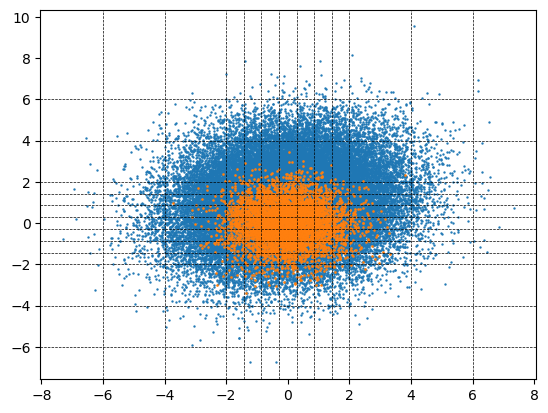

5000 49883 0.0911
Count= 0
Count= 100
Count= 200
Count= 300
Count= 400
Count= 0
Count= 100
Count= 200
Count= 300
Count= 400
Extracting signal...
Building...



Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_6mxlv9yv/model_v3ncaotp.stan', line 77, column 10: The
    variable partial_ll_counts may not have been assigned a value before its
    use.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Sampling:   0%
Sampling:   0% (1/4000)
Sampling:   0% (2/4000)
Sampling:   0% (3/4000)
Sampling:   0% (4/4000)
Sampling:   3% (103/4000)
Sampling:   5% (202/4000)
Sampling:   8% (301/4000)
Sampling:  10% (400/4000)
Sampling:  12% (500/4000)
Sampling:  15% (600/4000)
Sampling:  18% (700/4000)
Sampling:  20% (800/4000)
Sampling:  22% (900/4000)
Sampling:  25% (1000/4000)
Sampling:  28% (1100/4000)
Sampling:  30% (1200/4000)
Sampling:  32% (1300/4000)
Sampling:  35% (1400/4000)
Sampling:  38% (1500/4000)
Sampling:  40% (1600/4000)
Sampling:  42% (1700/4000)
S

Rhat (max, mean, std): 4.51 2.7769597423510466 0.6594355252890377


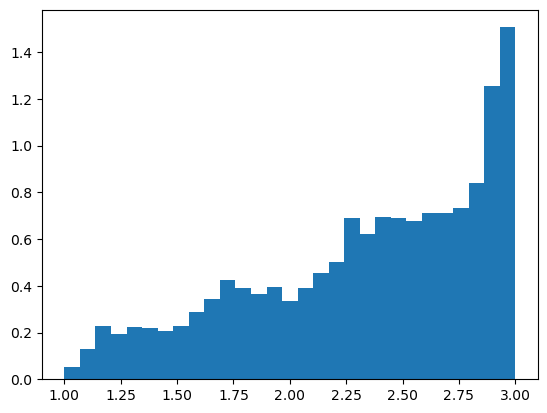

Extracting background...
Building...



Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_6mxlv9yv/model_v3ncaotp.stan', line 77, column 10: The
    variable partial_ll_counts may not have been assigned a value before its
    use.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Sampling:   0%
Sampling:   0% (1/4000)
Sampling:   0% (2/4000)
Sampling:   0% (3/4000)
Sampling:   0% (4/4000)
Sampling:   3% (103/4000)
Sampling:   5% (202/4000)
Sampling:   8% (301/4000)
Sampling:  10% (400/4000)
Sampling:  12% (500/4000)
Sampling:  15% (600/4000)
Sampling:  18% (700/4000)
Sampling:  20% (800/4000)
Sampling:  22% (900/4000)
Sampling:  25% (1000/4000)
Sampling:  28% (1100/4000)
Sampling:  30% (1200/4000)
Sampling:  32% (1300/4000)
Sampling:  35% (1400/4000)
Sampling:  35% (1401/4000)
Sampling:  38% (1501/4000)
Sampling:  40% (1600/4000)
S

Rhat (max, mean, std): 3.26 2.458159957058508 0.42032237987466925


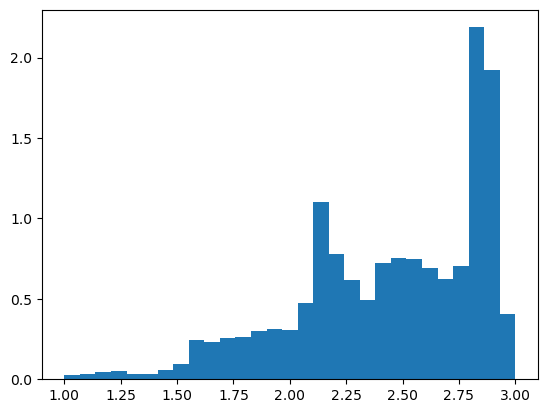

Unmixing in the MAP...
Building...



Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_l7rcz700/model_ihgdd64f.stan', line 49, column 0: The
    parameter pi is on the left-hand side of more than one tilde statement.
    is provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    prior is provided, or the prior(s) depend on data variables. In the later
    case, this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Sampling:   0%
Sampling: 100%, done.
Messages received during sampling:
  Gradient evaluation took 0.009378 seconds
  1000 transitions using 10 leapfrog steps per transition would take 93.78 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 0.010051 seconds
  1000 transitions using 10 leapfrog steps per transition would take 100.51 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 0.011513 seconds

Rhat (max, mean, std): 1.01 1.0005860805860805 0.002348896636173096


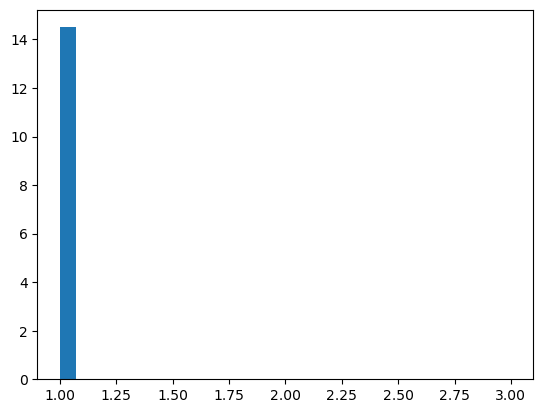

Unmixing Bayesianly...


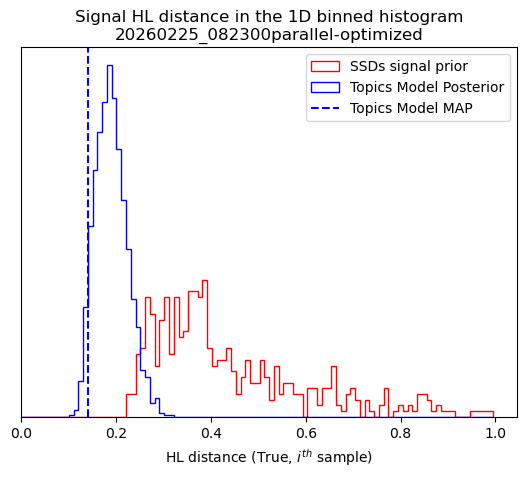

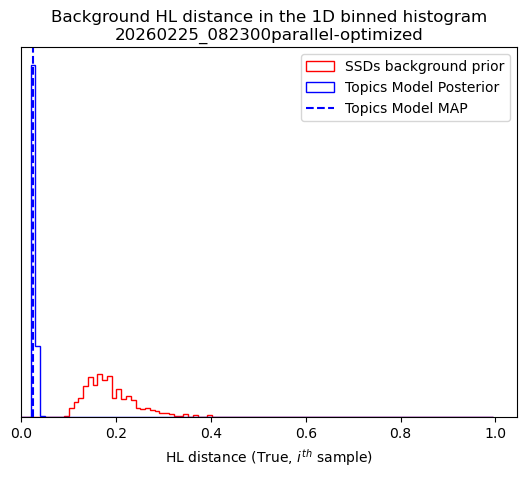

Unmixing Bayesianly...
Launching a parallel run...
Launching a parallel run...
Building...Building...





Building: found in cache, done.Building: found in cache, done.Messages from stanc:
Messages from stanc:
Warning in '/tmp/httpstan_l7rcz700/model_ihgdd64f.stan', line 49, column 0: The
    parameter pi is on the left-hand side of more than one tilde statement.
    is provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    prior is provided, or the prior(s) depend on data variables. In the later
    case, this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Warning in '/tmp/httpstan_l7rcz700/model_ihgdd64f.stan', line 49, column 0: The
    parameter pi is on the left-hand side of more than one tilde statement.
    is provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    prior is provided, or the prior(s) depend on data variables. In the later
    case, this may be a false positive.
    provided,

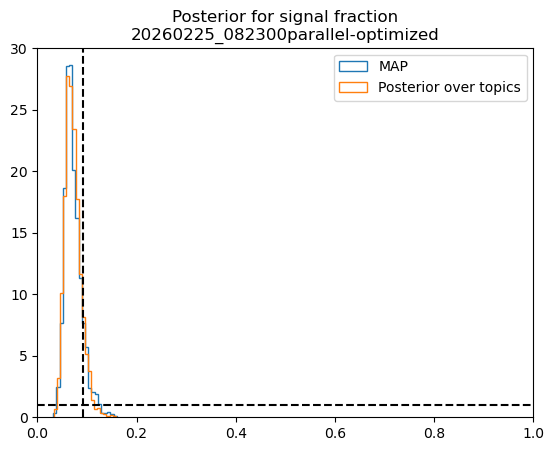

Execution times:


signal topic extraction:
603.01143125693

background topic extraction:
317.4834736943245

unmix PE
5.171549046039582

unmixed bayesian
9.68162904580434


In [3]:
# I prefer to don't create a main() functions, so that all variables values stay in the scope to eventually further explore them
runname = datetime.now().strftime("%Y%m%d_%H%M%S") + 'parallel-optimized'
print('runname: '+runname)
############
mybinning = [np.concatenate((np.linspace(-6,-4,2),np.linspace(-2,2,8),np.linspace(4,6,2))),np.concatenate((np.linspace(-6,-4,2),np.linspace(-2,2,8),np.linspace(4,6,2)))]
#mybinning = [np.linspace(-2,2,8),np.linspace(-2,2,8)] #fiduciary region only
# mean_sd_signal = [0, 0]
# covariance_sd_signal = [[1, 0], [0, 1]]
# mean_sd_background = [1, 0]
# covariance_sd_background = [[10, 2], [2,10]]
mean_sd_signal = [0, 0]
covariance_sd_signal = [[1, 0], [0, 1]]
mean_sd_background = [0, 1]
covariance_sd_background = [[3, 0.4], [0.4, 3]]
Ns0 = 5000
Nb0 = 50000
# Define which parameter is shifted and not just smeared arouund its true.
# The first element is a list with three elements: 1st: which element of the mean is shifted; 2nd: factor of shifting wrt to the true; 3rd: absolut shift wrt to the true
# The second element is the same, but in the covariance, hence the first two elements are the position of the parameter to be shifted.
# Enpty element means no shift.
exception_signal = [[1,0,-0.2],[]]   
exception_background = [[],[0,1,1.5,0]] 


Nssd_signal = 500
Nssd_background = 500
# STAN parameters
K2 = 15 # number of topics
M = 2 # how many W's posterior samples in the full bayesian signal fraction extraction
workers = 20
rseed = 0
nsamples = 500#1000 # number of samples in all the STAN inference running
nwarmup = 500#1000 # idem for warmup
mydelta = 0.8#0.9
mynote="""
Add some notes here to keep track of the run:

corrected bias_signal = -0.3 and bias_bkg = +0.3.
Also mydelta = 0.9 (it was 0.8 before!)"""
############################
############################
############################
############################
############################
############################

execution_times = ['Execution times:\n\n']
X, sd_signal, sd_background = generate_sd(mean_sd_signal, covariance_sd_signal, mean_sd_background, covariance_sd_background, Ns0, Nb0, mybinning=mybinning, rseed=rseed)
t_s  = flat_histogramdd(sd_signal, mybinning)
t_b = flat_histogramdd(sd_background, mybinning)
Ns = int(sum(t_s))
Nb = int(sum(t_b))
pi_true = np.round(Ns/(Ns + Nb),4)
p_signal = normalize_prob(t_s)
p_background = normalize_prob(t_b)
print(Ns, Nb, pi_true)

# Exclusion algorithm
exclusion = 0.3
var = 0.3
bias_signal = -0.3
bias_bkg = +0.3
ssd_length = max(Ns0, Nb0) * 10  # 10 times the larger sataset to reduce fluctuations at the SSD level

DF_ssd_signal, Ys = generate_ssd(
    mean_sd_signal, covariance_sd_signal, mybinning,
    exclusion, var, bias_signal, Nssd_signal, ssd_length)

DF_ssd_background, Yb = generate_ssd(
    mean_sd_background, covariance_sd_background, mybinning,
    exclusion, var, bias_bkg, Nssd_background, ssd_length)  # here there was a bug, it said bias_signal, where now says bias_bkg (feb22)


start_time = time.time()

############################
############################
############################
############################
############################
############################

cnt_s, v_idx_s, pos_s = convert(DF_ssd_signal, mybinning)
cnt_b, v_idx_b, pos_b = convert(DF_ssd_background, mybinning)

data_lda_signal =  {'N': Nssd_signal,
                    'V': (len(mybinning[0])-1) * (len(mybinning[1])-1),
                    'K': K2,
                    'NNZ': len(v_idx_s), 
                    'pos': pos_s,
                    'v_idx': v_idx_s,
                    'cnt': cnt_s,                    
                    'alpha': np.array([1]*K2),
                    'eta': np.array([1] * (len(mybinning[0])-1) * (len(mybinning[1])-1)),
                    "grainsize": 8}  # 122 = number of bins in the grid, 11 x 11 = 122

data_lda_background =  {'N': Nssd_signal,
                    'V': (len(mybinning[0])-1) * (len(mybinning[1])-1),
                    'K': K2,
                    'NNZ': len(v_idx_s), 
                    'pos': pos_b,
                    'v_idx': v_idx_b,
                    'cnt': cnt_b,                    
                    'alpha': np.array([1]*K2),
                    'eta': np.array([1] * (len(mybinning[0])-1) * (len(mybinning[1])-1)),
                    "grainsize": 8}

print('Extracting signal...')
samples_s, summary_s = lda_function(data_lda_signal, nsamples, nwarmup, mydelta, rseed=rseed)
end_time1 = time.time()
elapsed_time = (end_time1 - start_time) / 60
execution_times.extend(['signal topic extraction:', elapsed_time])

############# start partial write down ####################
mydict = create_var_dict(mybinning=mybinning, mean_sd_signal=mean_sd_signal, mean_sd_background=mean_sd_background,
                                 covariance_sd_background=covariance_sd_background, covariance_sd_signal=covariance_sd_signal,
                                 Ns0=Ns0, Nb0=Nb0,exception_signal = exception_signal, exception_background = exception_background,
                                 Nssd_signal=Nssd_signal, Nssd_background=Nssd_background, K2=K2, rseed=rseed, nsamples=nsamples,
                                 nwarmup=nwarmup, mydelta=mydelta, X=X, Ns=Ns, Nb=Nb, pi_true=pi_true, p_signal=p_signal, 
                                 p_background=p_background, Ys=Ys, Yb=Yb, samples_s=samples_s, mynote=mynote, execution_times=execution_times)
filename = 'results/'+runname+'_mydict.pkl'
with open(filename, 'wb') as file:
    pickle.dump(mydict, file)
############# end partial write down ######################


print('Extracting background...')
samples_b, summary_b = lda_function(data_lda_background, nsamples, nwarmup, mydelta, rseed=rseed)
end_time2 = time.time()
elapsed_time = (end_time2 - end_time1) / 60
execution_times.extend(['\nbackground topic extraction:', elapsed_time])





#columns_with_W = [s for s in list(samples_s) if s.startswith('W')]
#mysamples_s = samples_s[list(samples_s)[:7] + columns_with_W]
#columns_with_W = [s for s in list(samples_b) if s.startswith('W')]
#mysamples_b = samples_b[list(samples_b)[:7] + columns_with_W]

# save data with runname code
lda_data = {'samples_s':samples_s, 'samples_b':samples_b, 'mynote': mynote}
# Save as pickle
with open('results/lda_data_'+runname+'.pkl', 'wb') as f:
    pickle.dump(lda_data, f)

# Analyze results
with open('results/lda_data_'+runname+'.pkl', "rb") as f:
    mydata = pickle.load(f)
V = (len(mybinning[0])-1) * (len(mybinning[1])-1)
K = K2
W_background = []
for k in range(1,K+1):
    topic = []
    for v in range(1,V+1):
        topic.append(mydata['samples_b'].iloc[0]['W.'+str(k)+'.'+str(v)])
    W_background.append(topic)            

W_signal = []
for k in range(1,K+1):
    topic = []
    for v in range(1,V+1):
        topic.append(mydata['samples_s'].iloc[0]['W.'+str(k)+'.'+str(v)])
    W_signal.append(topic)  

# Let's unmix
data_unmix =  { 
                'V': (len(mybinning[0])-1) * (len(mybinning[1])-1),
                'K': K2,
                'N': len(X),
                'w': np.array(X),
                'W_signal': np.array(W_signal),
                'W_background': np.array(W_background),
                'alpha_signal': np.array([1]*K2),
                'alpha_background': np.array([1]*K2),
                'a_pi': 1,
                'b_pi': 1}    

print('Unmixing in the MAP...')
samples_unmix, summary = unmix_data(data_unmix, num_samples=nsamples, num_warmup=nwarmup, delta=mydelta, random_seed=rseed)

end_time3 = time.time()
elapsed_time = (end_time3 - end_time2) / 60
execution_times.extend(['\nunmix PE', elapsed_time])

print('Unmixing Bayesianly...')
assessment(p_signal, p_background, Ys, Yb, samples_unmix, runname)

end_time4 = time.time()
elapsed_time = (end_time4 - end_time3) / 60
execution_times.extend(['\nunmixed bayesian', elapsed_time])

for x in execution_times: print(x)
    
mydict = create_var_dict(mybinning=mybinning, mean_sd_signal=mean_sd_signal, mean_sd_background=mean_sd_background,
                                 covariance_sd_background=covariance_sd_background, covariance_sd_signal=covariance_sd_signal,
                                 Ns0=Ns0, Nb0=Nb0,exception_signal = exception_signal, exception_background = exception_background,
                                 Nssd_signal=Nssd_signal, Nssd_background=Nssd_background, K2=K2, rseed=rseed, nsamples=nsamples,
                                 nwarmup=nwarmup, mydelta=mydelta, X=X, Ns=Ns, Nb=Nb, pi_true=pi_true, p_signal=p_signal, 
                                 p_background=p_background, Ys=Ys, Yb=Yb, samples_s=samples_s, W_signal=W_signal,samples_unmix = samples_unmix,
                                 samples_b=samples_b, W_background=W_background, 
                                 mynote=mynote, execution_times=execution_times)
filename = 'results/'+runname+'_mydict.pkl'
with open(filename, 'wb') as file:
    pickle.dump(mydict, file)

# SCRATCH

In [ ]:
1

Unmixing Bayesianly...


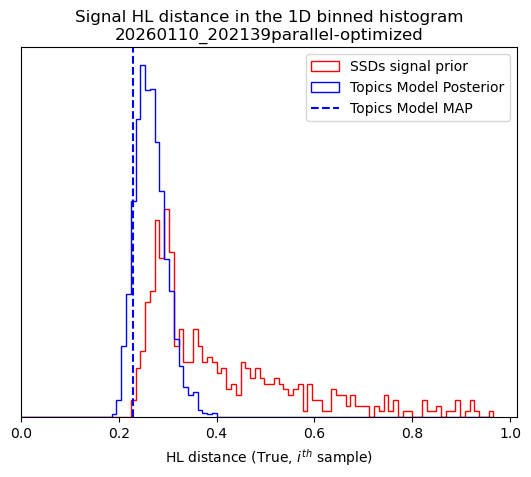

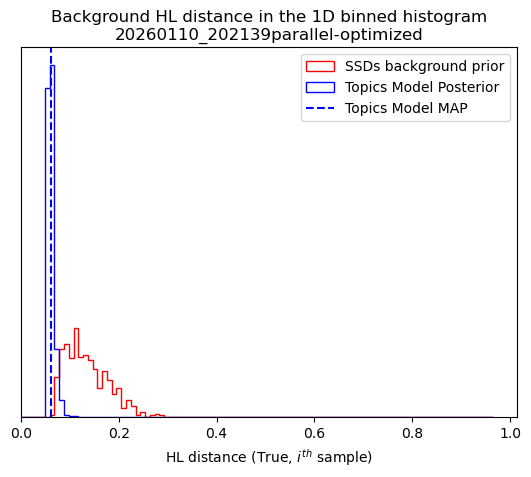

Unmixing Bayesianly...
Launching a parallel run...
Launching a parallel run...
Building...Launching a parallel run...
Building...Building...Launching a parallel run...
Launching a parallel run...
Launching a parallel run...
Building...Building...Building...Launching a parallel run...
Building...Launching a parallel run...
Launching a parallel run...
Launching a parallel run...
Building...Building...Launching a parallel run...
Launching a parallel run...
Building...Building...Launching a parallel run...
Building...Launching a parallel run...
Launching a parallel run...
Building...Building...Launching a parallel run...
Building...Launching a parallel run...
Building...Launching a parallel run...
Building...Launching a parallel run...
Building...Launching a parallel run...
Building...Building...









Building: found in cache, done.
Building: found in cache, done.
Messages from stanc:
Building: found in cache, done.Messages from stanc:


Warning in '/tmp/httpstan_l7rcz700/model_ihgdd64f.stan', line 49, column 0: The
    parameter pi is on the left-hand side of more than one tilde statement.
    is provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    prior is provided, or the prior(s) depend on data variables. In the later
    case, this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Warning in '/tmp/httpstan_l7rcz700/model_ihgdd64f.stan', line 49, column 0: The
    parameter pi is on the left-hand side of more than one tilde statement.
    is provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    prior is provided, or the prior(s) depend on data variables. In the later
    case, this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Messages f

Warning in '/tmp/httpstan_l7rcz700/model_ihgdd64f.stan', line 49, column 0: The
    parameter pi is on the left-hand side of more than one tilde statement.
    is provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    prior is provided, or the prior(s) depend on data variables. In the later
    case, this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Messages from stanc:
Building: found in cache, done.Messages from stanc:










Building: found in cache, done.Messages from stanc:

Building: found in cache, done.Building: found in cache, done.Building: found in cache, done.Building: found in cache, done.Building: found in cache, done.Warning in '/tmp/httpstan_l7rcz700/model_ihgdd64f.stan', line 49, column 0: The
    parameter pi is on the left-hand side of more than one tilde statement.
    is provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    prior is provided, or the prior(s) depend on data variables. In the later
    case, this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Warning in '/tmp/httpstan_l7rcz700/model_ihgdd64f.stan', line 49, column 0: The
    parameter pi is on the left-hand side of more than one tilde statement.
    is provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    prior is provided, or the

...


Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_l7rcz700/model_ihgdd64f.stan', line 49, column 0: The
    parameter pi is on the left-hand side of more than one tilde statement.
    is provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    prior is provided, or the prior(s) depend on data variables. In the later
    case, this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Sampling:   0%

Launching a parallel run...
Building...



Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_l7rcz700/model_ihgdd64f.stan', line 49, column 0: The
    parameter pi is on the left-hand side of more than one tilde statement.
    is provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    prior is provided, or the prior(s) depend on data variables. In the later
    case, this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Sampling:   0%
Sampling: 100%, done.
Messages received during sampling:
  Gradient evaluation took 0.000523 seconds
  1000 transitions using 10 leapfrog steps per transition would take 5.23 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 0.000467 seconds
  1000 transitions using 10 leapfrog steps per transition would take 4.67 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 0.00048 seconds
  1

Launching a parallel run...
Building...



Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_l7rcz700/model_ihgdd64f.stan', line 49, column 0: The
    parameter pi is on the left-hand side of more than one tilde statement.
    is provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    prior is provided, or the prior(s) depend on data variables. In the later
    case, this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Sampling:   0%
Sampling: 100%, done.
Messages received during sampling:
  Gradient evaluation took 0.000446 seconds
  1000 transitions using 10 leapfrog steps per transition would take 4.46 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 0.000452 seconds
  1000 transitions using 10 leapfrog steps per transition would take 4.52 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 0.000527 seconds
  

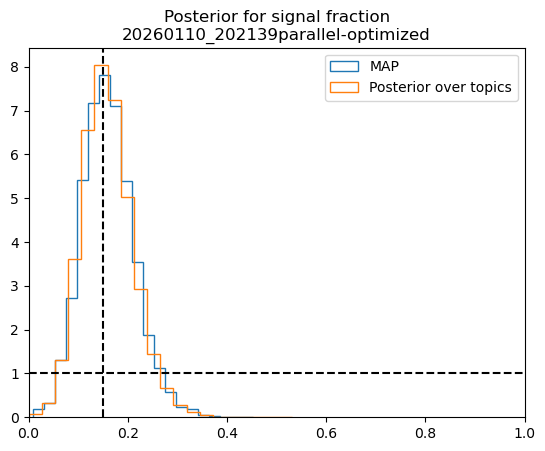

In [8]:
print('Unmixing Bayesianly...')
M=200
assessment(p_signal, p_background, Ys, Yb, samples_unmix, runname)

In [4]:
1

1

In [13]:
M

50